# Lesson 10: Fixed vs random effects (`fixed_regressors` / `random_regressors`)

bauer's regression models let you put a patsy formula on any model parameter — for
example, regress the encoding noise `n1_evidence_sd` on subject group, ISI, or
session. The question this lesson answers is: **for each term in that formula, is
the coefficient a single population-level number, or does it vary from subject to
subject?**

That is the distinction between a **fixed** and a **random** effect, and getting it
right matters both statistically (it changes what the posterior means) and
numerically (the wrong choice produces a poorly-identified, badly-mixing model).
bauer 0.3.0 introduces an explicit API for it:

* `fixed_regressors={param: formula}` — the **population-mean** design. Each column
  gets one coefficient shared by everyone (`group_mu`), with no per-subject offset.
* `random_regressors={param: formula}` — which of those columns **additionally**
  carry a **per-subject random effect** (`group_mu + group_sd * offset`, i.e.
  partial pooling). Omitted ⇒ defaults to `'1'` (a random intercept only).

The old `regressors={param: formula}` keyword still works but is **deprecated**: it
silently put a random slope on *every* column — which is wrong for
between-subjects covariates, as we'll see.


## Setup

We import bauer from this worktree (the 0.3.0 release branch) and force JAX onto the
CPU so the tiny example fits run anywhere. Everything below is sized to run in well
under a minute on a laptop.


In [ ]:
import os, sys
os.environ.setdefault('JAX_PLATFORMS', 'cpu')   # tiny CPU fits only
# Make sure we import the 0.3.0 worktree, not an older editable install.
# The notebook lives in <repo>/docs/tutorial, so the repo root is two levels up.
for _root in (os.path.abspath(os.path.join(os.getcwd(), '..', '..')), os.getcwd()):
    if os.path.isdir(os.path.join(_root, 'bauer')):
        sys.path.insert(0, _root)
        break

import warnings
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

import bauer
from bauer.models import MagnitudeComparisonRegressionModel
print('bauer', bauer.__version__, 'from', os.path.dirname(bauer.__file__))

bauer 0.3.0 from /private/tmp/bauer-rel-smoke/bauer


## 1. Fixed vs random, conceptually

Say we regress a parameter $\theta$ (here, log encoding noise) on a single binary
covariate $x$ with a design `Intercept + x`. For subject $s$ on trial with covariate
value $x$, bauer builds the coefficient vector as

$$\theta_s = \underbrace{\mu}_{\text{group mean}} \; + \; \underbrace{\sigma\,z_s}_{\text{per-subject deviation}}$$

applied column by column, where $z_s \sim \mathcal{N}(0, 1)$ is a standardised
per-subject offset and $\sigma$ is a group-level SD (the non-centred parameterisation).

* A **fixed** effect on a column keeps only the $\mu$ term: one number for everyone,
  no $\sigma z_s$. Use this when you believe the effect is the same in the population
  (e.g. *the* average difference between two groups).
* A **random** effect on a column adds the $\sigma z_s$ term: the coefficient is
  *partially pooled*, each subject shrunk toward the group mean by an amount the data
  decide. Use this for quantities that genuinely differ subject-to-subject (e.g. each
  person's baseline noise level — the **intercept** — or each person's sensitivity to
  a within-subject manipulation).

In bauer 0.3.0, `fixed_regressors` columns get *only* `group_mu`; the columns named
in `random_regressors` *also* get `group_sd * offset`.


## 2. A tiny synthetic dataset

Six subjects, two groups (3 "control", 3 "patient"). Group is a **between-subjects**
covariate: it is constant within each subject — a person is a patient on every one of
their trials. We make the patients genuinely noisier, plus a per-subject baseline so
there is real between-subject variability in the *intercept*.


In [ ]:
rng = np.random.default_rng(0)

n_sub = 6
groups = ['control'] * 3 + ['patient'] * 3
base_ns = np.array([5, 7, 10, 14, 20])
fracs = np.array([0.7, 0.85, 1.0, 1.18, 1.4])

rows = []
for s in range(n_sub):
    grp = groups[s]
    grp_offset = 0.5 if grp == 'patient' else 0.0     # true fixed group effect
    subj_intercept = rng.normal(0, 0.3)               # true random intercept
    log_noise = -0.7 + grp_offset + subj_intercept
    noise = np.log1p(np.exp(log_noise))               # softplus -> positive SD
    for n1 in base_ns:
        for f in fracs:
            for _ in range(6):
                n2 = n1 * f
                d = (np.log(n2) - np.log(n1)) / (np.sqrt(2) * noise)
                p = 1 / (1 + np.exp(-2.5 * d))
                rows.append((s + 1, n1, n2, int(rng.random() < p), grp))

df = pd.DataFrame(rows, columns=['subject', 'n1', 'n2', 'choice', 'group'])
df = df.set_index(['subject', df.groupby('subject').cumcount().rename('trial')])
print(df.head())
print('trials per subject:', df.groupby('subject').size().tolist())
print('group is constant within subject:',
      bool((df.reset_index().groupby('subject')['group'].nunique() == 1).all()))

               n1   n2  choice    group
subject trial                          
1       0       5  3.5       0  control
        1       5  3.5       1  control
        2       5  3.5       1  control
        3       5  3.5       0  control
        4       5  3.5       0  control
trials per subject: [150, 150, 150, 150, 150, 150]
group is constant within subject: True


Note the last line: `group` has exactly one value per subject. That is the defining
feature of a *between-subjects* covariate, and it is what makes a random slope on it a
mistake.


## 3. The deprecated `regressors=` keyword

Before 0.3.0 you wrote `regressors={param: formula}`. That single keyword did two
things at once: it added the columns to the **population-mean** design *and* gave
**every** column a per-subject random effect. It still works (bit-for-bit) but now
emits a `DeprecationWarning`.


In [ ]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    m_legacy = MagnitudeComparisonRegressionModel(
        df, regressors={'n1_evidence_sd': 'C(group)'})

for w in caught:
    if issubclass(w.category, DeprecationWarning):
        print('DeprecationWarning:', str(w.message).split('.')[0])

The deprecation message tells you exactly what to do: split the formula into a
`fixed_regressors` part (population means) and a `random_regressors` part (per-subject
effects). The legacy call is equivalent to
`fixed_regressors = random_regressors = {'n1_evidence_sd': 'C(group)'}` — a random
slope on the group contrast, which is the pitfall we turn to now.


## 4. The pitfall: a random slope on a between-subjects covariate

Consider what a random slope on `C(group)` actually asks for. The design has two
columns, `Intercept` and `C(group)[T.patient]`. A random slope means *every* subject
gets a per-subject offset on **both** columns:

$$\theta_s = (\mu_0 + \sigma_0 z_{s,0})\,\text{Intercept} \;+\; (\mu_1 + \sigma_1 z_{s,1})\,\text{patient}_s$$

But `patient`$_s$ is **0 for every control subject**. So:

* For the three control subjects, the `patient` column is identically zero — their
  offset $z_{s,1}$ is multiplied by 0 on every trial. It enters the likelihood
  nowhere. Those are **non-identified nuisance dimensions**: NUTS just samples them
  from the prior, wasting geometry and dragging down the effective sample size.
* For the three patient subjects, the `patient` column is 1, so they each carry an
  *extra* random-effect term that controls don't. The model now believes patients are
  **heteroscedastically more variable** than controls — an artefact of the
  parameterisation, not of the data.
* Worst of all, the per-subject `patient` offset $\sigma_1 z_{s,1}$ is, for each
  patient, perfectly **confounded with that subject's intercept offset**
  $\sigma_0 z_{s,0}$: both are constants added to all of that subject's trials. The
  data cannot tell them apart. This degeneracy **inflates the posterior on the group
  contrast** $\mu_1$ and under-identifies it.

The fix is to make the group difference a **fixed** effect and keep a **random
intercept**:

```python
fixed_regressors  = {'n1_evidence_sd': 'C(group)'}   # population mean: intercept + group
random_regressors = {'n1_evidence_sd': '1'}          # per-subject: intercept only
```

Now the group difference is a single population number (as it should be — there is
only *one* control-vs-patient contrast in the world), and the genuine
between-subject variability lives where it belongs: in the random intercept.
bauer warns you if you ask for the wrong thing.


In [ ]:
# WRONG: random slope on a between-subjects covariate
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    m_wrong = MagnitudeComparisonRegressionModel(
        df,
        fixed_regressors={'n1_evidence_sd': 'C(group)'},
        random_regressors={'n1_evidence_sd': 'C(group)'})
    m_wrong.build_estimation_model(df, hierarchical=True)

for w in caught:
    if issubclass(w.category, UserWarning) and not issubclass(w.category, DeprecationWarning):
        print('UserWarning:', str(w.message)[:200], '...')

In [ ]:
# RIGHT: fixed group contrast + random intercept (no warning)
m_right = MagnitudeComparisonRegressionModel(
    df,
    fixed_regressors={'n1_evidence_sd': 'C(group)'},
    random_regressors={'n1_evidence_sd': '1'})
m_right.build_estimation_model(df, hierarchical=True)
print('built cleanly')

built cleanly


## 5. The two parameterisations, in the model graph

We don't even need to sample to see the difference. The per-subject offset variable
`n1_evidence_sd_offset` carries different dimensions in the two models. In the WRONG
model it spans the full regressor coordinate (Intercept **and** group); in the RIGHT
model it spans a dedicated random-effects coordinate (`_re`) containing only the
intercept.


In [ ]:
def offset_dims(model, name='n1_evidence_sd'):
    var = f'{name}_offset'
    dims = model.named_vars_to_dims[var]
    coords = {d: list(model.coords[d]) for d in dims if d in model.coords}
    return dims, coords

for label, m in [('WRONG (random slope on group)', m_wrong),
                 ('RIGHT (fixed group + random intercept)', m_right)]:
    dims, coords = offset_dims(m.estimation_model)
    print(label)
    print('   offset dims  :', tuple(dims))
    last = list(dims)[-1]
    print('   columns with a per-subject random effect:', coords[last])
    print()

WRONG (random slope on group)
   offset dims  : ('subject', 'n1_evidence_sd_regressors')
   columns with a per-subject random effect: ['Intercept', 'C(group)[T.patient]']

RIGHT (fixed group + random intercept)
   offset dims  : ('subject', 'n1_evidence_sd_re')
   columns with a per-subject random effect: ['Intercept']



The WRONG model gives all 6 subjects a per-subject `C(group)[T.patient]` offset —
including the 3 controls, for whom that column is always zero. The RIGHT model has a
random effect *only* on the Intercept, exactly as intended. The group contrast lives
purely in the population-mean node `n1_evidence_sd_mu`.


## 6. A quick fit: the contrast is wider / less identified in the WRONG model

Now a short real fit of both models (numpyro backend, `draws = tune = 200`, 2 chains).
This runs in a few seconds each on CPU. We compare the posterior on the group contrast
`n1_evidence_sd_mu[C(group)[T.patient]]`.


In [ ]:
def quick_fit(m):
    m.sample(draws=200, tune=200, chains=2, backend='numpyro',
             target_accept=0.9, random_seed=1, progressbar=False)
    return m.idata

with warnings.catch_warnings():
    warnings.simplefilter('ignore')   # silence the few-chains / low-ESS notices
    idata_wrong = quick_fit(m_wrong)
    idata_right = quick_fit(m_right)
print('done sampling')

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


done sampling


In [ ]:
def contrast_samples(idata):
    return idata.posterior['n1_evidence_sd_mu'].sel(
        n1_evidence_sd_regressors='C(group)[T.patient]').values.ravel()

c_wrong = contrast_samples(idata_wrong)
c_right = contrast_samples(idata_right)

summary = pd.DataFrame({
    'posterior SD (contrast)': [c_wrong.std(), c_right.std()],
    '95% HDI width':           [np.diff(az.hdi(c_wrong, hdi_prob=.95))[0],
                                np.diff(az.hdi(c_right, hdi_prob=.95))[0]],
    'ESS (bulk)': [
        float(az.ess(idata_wrong, var_names=['n1_evidence_sd_mu']
                     )['n1_evidence_sd_mu'].sel(
            n1_evidence_sd_regressors='C(group)[T.patient]')),
        float(az.ess(idata_right, var_names=['n1_evidence_sd_mu']
                     )['n1_evidence_sd_mu'].sel(
            n1_evidence_sd_regressors='C(group)[T.patient]')),
    ],
}, index=['WRONG: random slope on group', 'RIGHT: fixed group + random intercept'])
summary.round(3)

,posterior SD (contrast),95% HDI width,ESS (bulk)
WRONG: random slope on group,0.269,1.053,194.000
RIGHT: fixed group + random intercept,0.236,0.922,373.975


The WRONG model's group contrast has a **wider** posterior and **lower effective
sample size** — the confounding with the per-subject intercept offsets inflates and
under-identifies it. The exact numbers wiggle with such a tiny fit, but the direction
is the systematic consequence of the bad parameterisation. Let's plot the two
contrast posteriors.


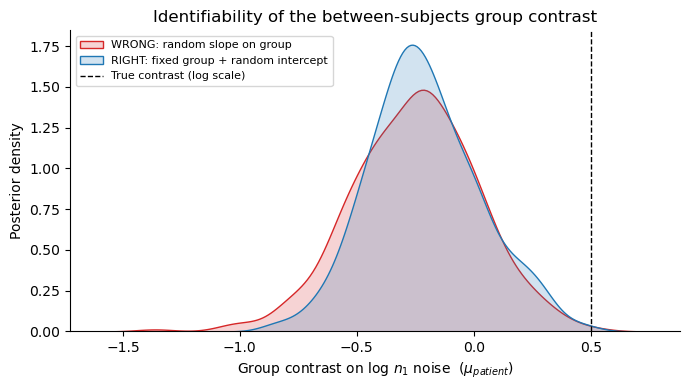

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for c, label, color in [(c_wrong, 'WRONG: random slope on group', 'C3'),
                        (c_right, 'RIGHT: fixed group + random intercept', 'C0')]:
    sns.kdeplot(c, ax=ax, label=label, color=color, fill=True, alpha=0.2)
ax.axvline(0.5, color='k', ls='--', lw=1, label='True contrast (log scale)')
ax.set_xlabel('Group contrast on log $n_1$ noise  ($\mu_{patient}$)')
ax.set_ylabel('Posterior density')
ax.set_title('Identifiability of the between-subjects group contrast')
ax.legend(fontsize=8)
sns.despine()
plt.tight_layout()

## 7. When *is* a random slope correct?

Random slopes are not bad — they are bad *only on between-subjects covariates*. For a
**within-subject** manipulation (one that takes different values across a single
subject's own trials — ISI, session, trial type, stimulus condition) a random slope is
exactly right: it lets each subject have their own sensitivity, partially pooled toward
the group. There the per-subject offset is identified, because the covariate genuinely
varies within the subject.

So the rule of thumb is:

| Covariate type | Varies within subject? | Put it in… |
|---|---|---|
| Between-subjects (group, sex, patient/control) | No | `fixed_regressors` only; keep `random_regressors={p: '1'}` |
| Within-subject (ISI, session, condition) | Yes | `fixed_regressors` **and** (if you want per-subject slopes) `random_regressors` |

You can mix them in one formula. For example, a fixed group contrast plus a random
slope on a within-subject ISI:

```python
fixed_regressors  = {'n1_evidence_sd': 'C(group) + isi'}
random_regressors = {'n1_evidence_sd': 'isi'}   # per-subject ISI slope + (implicit) intercept
```

bauer validates that every `random_regressors` term is a subset of the fixed design,
and warns whenever a requested random term turns out to be constant within subject —
catching the footgun before it costs you a night of debugging non-convergence.


## Summary

* **Fixed effect** = one population-level coefficient (`group_mu`), shared by all
  subjects. **Random effect** = population mean plus a partially-pooled per-subject
  deviation (`group_mu + group_sd * offset`).
* In bauer 0.3.0, declare them explicitly: `fixed_regressors` for the population-mean
  design, `random_regressors` for the per-subject part (default: random intercept only).
* The legacy `regressors=` keyword is **deprecated** — it put a random slope on every
  column, which is wrong for between-subjects covariates.
* A random slope on a **between-subjects** covariate (constant within subject) creates
  non-identified per-subject offsets, heteroscedastic-by-group variance, and an
  inflated/under-identified group contrast. The correct pattern is a **fixed** group
  effect with a **random intercept**.
* Random slopes are appropriate for **within-subject** covariates, where the
  per-subject offset is actually identified.
